In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import matplotlib.animation as ani
from tqdm import tqdm

# create some 1D arrays
x1d = np.linspace(-1, 1, 500)
y1d = np.linspace(-1, 1, 500)

# create 2D arrays of x and y
x2d, y2d = np.meshgrid(x1d, y1d)

In [2]:
def intensity_imshow(c1, c2, title):
    '''
    This function is a help to demonstrate how
    imshow-ing arrays works in matplotlib.
    '''

    # create a new figure
    plt.figure(figsize=(10,4), dpi=300)

    x_limb_darkening = np.sqrt(x2d**2 + y2d**2)
    mu = np.sqrt(1 - (x_limb_darkening**2))
    I = (1 - c1*(1-mu) - c2*(1-mu)**2)
    offstar = x_limb_darkening > 1
    I[offstar] = 0


    # make an array of c1 and c2 and loop through to produce an image for those 

    # make an image, with brightness representing array values
    plt.imshow(I, 
               cmap='gray', # Choose the color map.
               origin='lower', # Set (x,y) = (0,0) to be the lower left.
               extent=[np.min(x1d), # Extent sets the coordinates for the corners
                       np.max(x1d), #  of the array you're plotting
                       np.min(y1d), #  [left, right, bottom, top]
                       np.max(y1d)],
               aspect='equal', # How is the aspect ratio of the plot set?
               interpolation='nearest') # How are points visually interpolated?



    # add a colorbar indicating the scale of the colors
    plt.colorbar(label=title)

    # plot labels
    plt.xlabel('x (stellar radii)')
    plt.ylabel('y (stellar radii)')
    plt.title(title)

def intensity_imshow_array(data, filename, figure, dpi):

    t = ascii.read(data)
    writer = ani.FFMpegWriter(fps=15, bitrate=1000)
    figure = plt.figure(figsize=(10,4),dpi=500)
    N = len(t) 

    # create a new figure
    figure = plt.figure()

    with writer.saving(figure, filename, dpi):
        for i in tqdm(range(N)):
            w = t['wavelength'][i]
            c1 = t['c1'][i]
            c2 = t['c2'][i]

            x_limb_darkening = np.sqrt(x2d**2 + y2d**2)
            mu = np.sqrt(1 - (x_limb_darkening**2))
            I = (1 - c1*(1-mu) - c2*(1-mu)**2)
            offstar = x_limb_darkening > 1
            I[offstar] = 0

            plt.clf()

            plt.imshow(I, vmin=0, vmax=1,
            cmap='gray', # Choose the color map.
            origin='lower', # Set (x,y) = (0,0) to be the lower left.
            extent=[np.min(x1d), # Extent sets the coordinates for the corners
                   np.max(x1d), #  of the array you're plotting
                   np.min(y1d), #  [left, right, bottom, top]
                   np.max(y1d)],
            aspect='equal', # How is the aspect ratio of the plot set?
            interpolation='nearest') # How are points visually interpolated?

            plt.colorbar()

            # plot labels
            plt.xlabel('x (stellar radii)')
            plt.ylabel('y (stellar radii)')
            plt.title(f'\u03BB = {w:.2f} nm, c1 = {c1:.5f}, c2 = {c2:.5f}')
            writer.grab_frame()

/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_62325/3396200964.py:11: RuntimeWarning: invalid value encountered in sqrt
  mu = np.sqrt(1 - (x_limb_darkening**2))


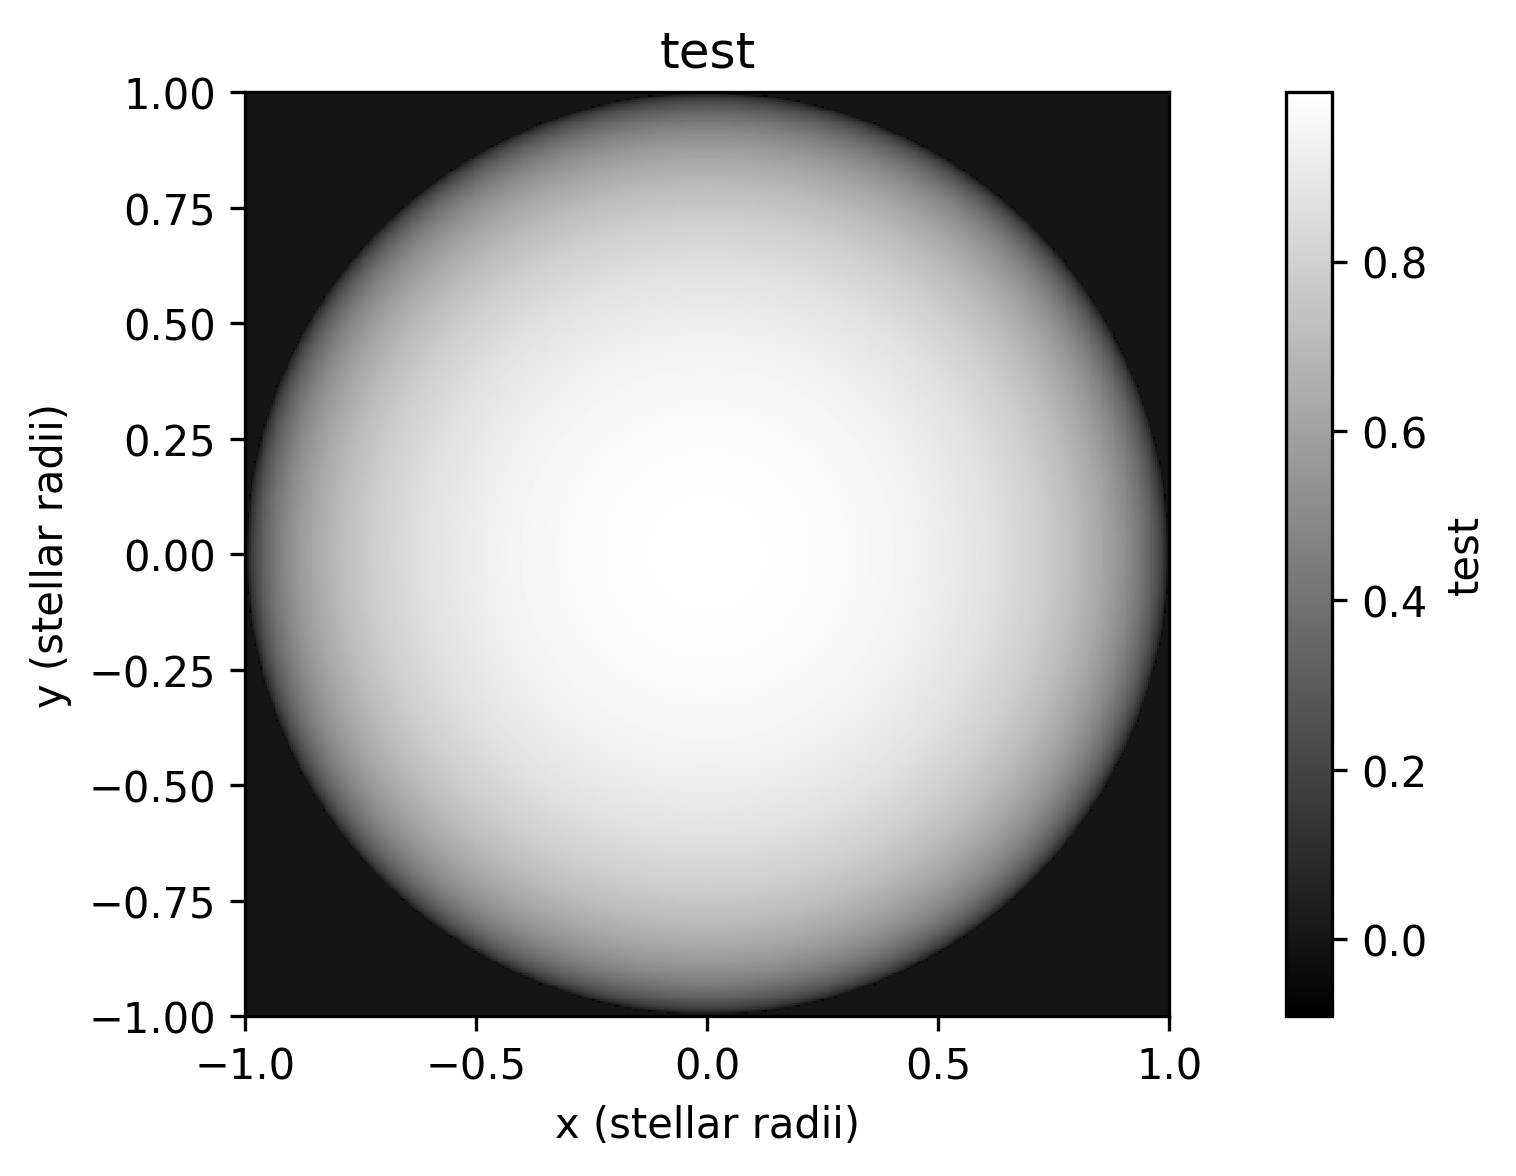

In [7]:
intensity_imshow(0.5, 0.6, 'test')

In [4]:
def intensity_imshow_split(c1_left, c2_left, c1_right, c2_right, title):
    '''
    This function displays two different 
    limb-darkening laws on the left and right sides.
    
    '''

    # create a new figure
    plt.figure(figsize=(10,4), dpi=300)

    # set up the basic variables
    x_limb_darkening = np.sqrt(x2d**2 + y2d**2)
    mu = np.sqrt(1 - (x_limb_darkening**2))
    
    # calculate 2D arrays for both sets of coefficients
    I_left = (1 - c1_left*(1-mu) - c2_left*(1-mu)**2)
    I_right = (1 - c1_right*(1-mu) - c2_right*(1-mu)**2)
    
    # stitch the two images together
    I = I_left*(x2d < 0) + I_right*(x2d > 0)
    offstar = x_limb_darkening > 1
    I[offstar] = 0


    # make an array of c1 and c2 and loop through to produce an image for those 

    # make an image, with brightness representing array values
    plt.imshow(I, 
               cmap='gray', # Choose the color map.
               origin='lower', # Set (x,y) = (0,0) to be the lower left.
               extent=[np.min(x1d), # Extent sets the coordinates for the corners
                       np.max(x1d), #  of the array you're plotting
                       np.min(y1d), #  [left, right, bottom, top]
                       np.max(y1d)],
               aspect='equal', # How is the aspect ratio of the plot set?
               interpolation='nearest') # How are points visually interpolated?



    # add a colorbar indicating the scale of the colors
    plt.colorbar(label=title)

    # plot labels
    plt.xlabel('x (stellar radii)')
    plt.ylabel('y (stellar radii)')
    plt.title(title)



/var/folders/vq/zxq380ws52q37mjjtbt9c7rh0000gp/T/ipykernel_89412/2906839223.py:13: RuntimeWarning: invalid value encountered in sqrt
  mu = np.sqrt(1 - (x_limb_darkening**2))


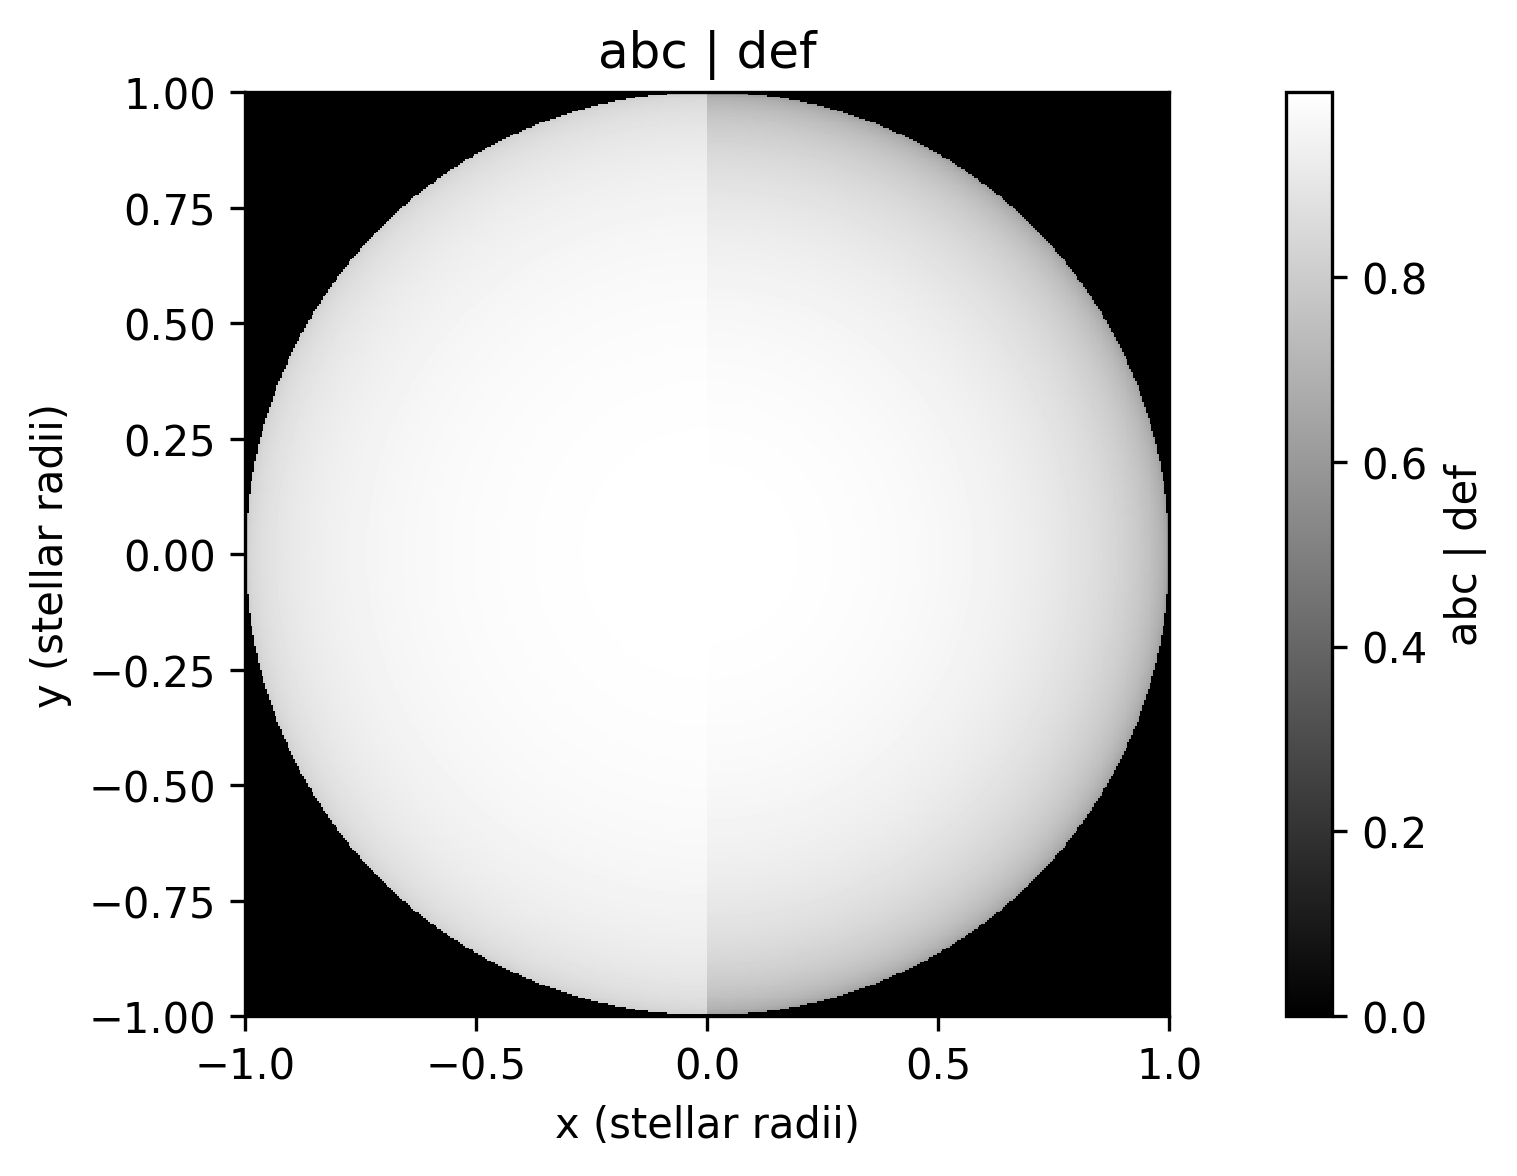

In [5]:
intensity_imshow_split(0.1, 0.1, 0.2, 0.2,  'abc | def')